In [507]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns

In [509]:
train_df = pd.read_csv('train_transform.csv')
train_df.set_index('Id', inplace=True)
train_df.head(3)

,MSSubClass,LotFrontage,LotArea,Neighborhood,Condition1,Condition2,HouseStyle,OverallQual,OverallCond,YearBuilt,...,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_P,PavedDrive_Y
Id,,,,,,,,,,,,,,,,,,,,,
1,60,65.0,8450,193562.333333,172579.094556,169601.131997,197411.994318,7,5,2003,...,0,0,0,1,0,0,0,1,0,1
2,20,80.0,9600,213055.555556,141297.955882,169601.131997,164390.432079,6,8,1976,...,0,0,0,1,0,0,0,1,0,1
3,60,68.0,11250,193562.333333,172579.094556,169601.131997,197411.994318,7,5,2001,...,0,0,0,1,0,0,0,1,0,1


После считывания датафрейма напишем **функцию**, которая считает **скалярное произведение** (матрицы признаков **X** на вектор весов **W**). 

P.S. Можно **увеличить** скорость работы программы с помощью **матричного умножения** , использую библиотеку `numpy`, сложность равна O(len(x) * len(x)), чтобы быстрее шел расчет на больших данных, но при этом сложность алгоритма **ассимптотически не изменится**. Но у нас хард, поэтому эту библиотеку не используем :)

In [512]:
def predict(x, w):
    n = len(w) #это кол-во признаков
    finish_answer = []
    for j in range(len(x)): #len(x) - это кол-во объектов
        now_sum = [] #сюда будем добавлять результаты скалярного произведения признаков объекта на вектор весов
        for i in range(n):
            if i == 0:
                now_sum.append(w[0]) #первый элемент вектора весов не умножается ни на что, поэтому просто добавляем его
            else:
                now_sum.append(w[i] * x[j][i-1]) #умножаем тек. эл-т в. весов на предыдущее значение признака
        total_sum = sum(now_sum) #суммируем, чтобы вычислить предсказание стоимости
        finish_answer.append(np.round(total_sum, 0))
    return np.array(finish_answer)

Чтобы код был более читаемым, напишем еще одну функцию - `grad_find`, которая будет вычислять веса W методом градиентного спуска

`learning rate` подобран **в ручную**, можно поэксперементировать над ним, возможно результаты будут лучше

In [515]:
def grad_find(x, y, w, learning_rate, n):
    for i in tqdm(range(n)): #здесь именно итерации, не по массиву
        predictions = predict(x, w) #вычисляем предсказания с текущими весами 
        errors = predictions - y #вычисляем ошибки, т.е. разницу между предсказаниями и реальными значениями

        grad_w0 = 2/N * np.sum(errors)
        grad_w = 2/N * np.sum(errors[:, np.newaxis] * x, axis=0) #здесь вычисляем градиенты, для 1-го элемента w0 - отдельно
        for j in range(len(w)): #считаем новые веса
            if j == 0:
                w[0] = w[0] - grad_w0 * learning_rate 
            else:
                w[j] = w[j] - learning_rate * grad_w[j-1]
    return w

Зададим **тестовые данные**: матрица **Х** размером 4х5, вектор ответов **У** длиной 5, вектор весов **W**, длиной 5

In [518]:
x = np.array([[1, 4, 5, 1],
              [4, 5, 2, 7],
              [8, 9, 5, 2],
              [4, 5, 6, 6],
              [5, 1, 3, 2]])
w = [0, 0, 0, 0, 0]
y = np.array([10, 20, 30, 50, 40])
learning_rate = 0.01
n = 1200
new_w = grad_find(x, y, w, learning_rate, n)
predict(x, new_w)

100%|████████████████████████████████████| 1200/1200 [00:00<00:00, 25865.88it/s]


array([12., 21., 30., 48., 41.])

Конечно, тестовых данных немного, но за счет **большого количества итераций**, результат получается довольно точным. Если мы будем **увеличивать** кол-во итераций, результат будет **точнее**

Далее уже будем брать наш датафрейм (егот размер 1206 на 108, где есть 1206 объектов, поэтому итераций будем брать минимум 1206). Но перед эти его нужно **стандартизировать**. Проделаем это с помощью библиотеки `skikit-learn`.

**Подробное описание:**
1. Это преобразование каждого признака таким образом, чтобы его **среднее** - $\mu$ стало равно `0`, а **стандартное отклонение** - $\sigma$ будет равно `1`
2. **Формула** следующая: *x_scaled* *=* (*x - $\mu$*)/$\sigma$, где *x_scaled* - новое значение x, $\mu$ - **среднее** по начальному набору данных (по начальному признаку), $\sigma$ - **стандартное отклонение** в начальном датафрейме.
3. По сути, мы приводим нашу выборку (т.е. колонку, признак) к **нормальному распределению** со средним 0 и стандартным отклонением 1
4. По-другому это называется **Z-scored преобразование**, в прикладной статистике так же есть **Z-критерий Фишера**, который помогает нам проверять различные гипотезы при нормальном распределении
5. Реализовать без библиотеки **довольно просто**, но будем использовать именно ее, для примера как она работает

In [522]:
from sklearn.preprocessing import StandardScaler

x = np.array(train_df[[col for col in train_df.columns if col != 'SalePrice']])
y = np.array(train_df['SalePrice'])

scaler = StandardScaler()
scaler.fit(x)
x_scaled = scaler.transform(x)
w = [0] * (x_scaled.shape[1] + 1)
learning_rate = 0.0001
x_scaled.T[0]

array([ 0.10558251, -0.87578558,  0.10558251, ...,  0.10558251,
        0.35092454, -0.87578558])

После стандратизации у нас должны получиться **небольшие значения**. Тогда у нас не будет происходить ошибка переполнения типов - `overflow`, из-за нее вектор весов заполняется значением **NaN**

In [525]:
n = 1206
learning_rate = 0.0001
w_new = grad_find(x_scaled, y, w, learning_rate, n)

100%|███████████████████████████████████████| 1206/1206 [00:43<00:00, 27.41it/s]


Выведем 3 значения из вектора ответов и 3 предсказанных значения:

In [528]:
print(predict(x_scaled, w_new)[0:3])
print(y[0:3])

[208918. 195274. 214652.]
[208500. 181500. 223500.]


Так же нарисуем график, как у нас распределяются **реальные** значения и **предсказанные**. Используем `sns.scatterplot`

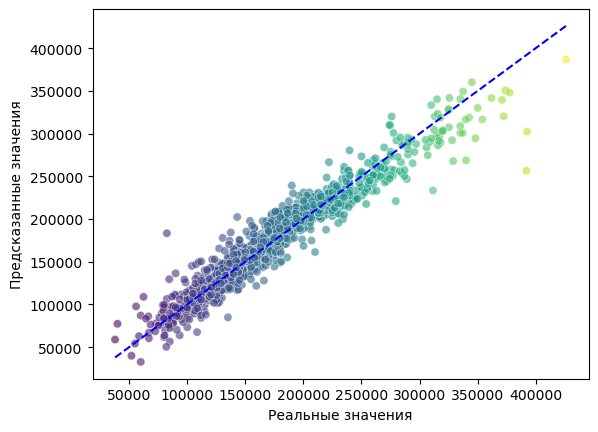

In [531]:
y_pred = predict(x_scaled, w_new)
sns.scatterplot(x=y, y=y_pred, alpha=0.6, palette='viridis', hue=y, legend=False);
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'b--');
plt.xlabel('Реальные значения');
plt.ylabel('Предсказанные значения');

Посмотрим на **распределение** данных вдоль прямой. Мы увидим, что у нас довольно **близкие** к друг другу значения. Чтобы сделать **окончательный** выоvд, посчитаем **среднюю ошибку - MAE**

In [534]:
errors = np.abs(y - y_pred)
MAE_error = sum(errors) / len(train_df)
np.round(MAE_error, 2)

11819.49

**Средняя абсолютная ошибка** довольно низкая (если будем использовать **аналитический метод** на начальном датафрейме, тогда она будет равна 12039).
Значит наша модель на **стандартизированных данных** работает лучше

Построим еще на примере `x_scaled[0]` график нормального распределения, просто для визуализации

`mu` - среднее выборки

`stdd` - стандартное отклонение

In [539]:
from scipy.stats import norm
mu, stdd = np.mean(x_scaled.T[1]), np.std(x_scaled.T[1])
xx = np.linspace(min(x_scaled.T[1]), max(x_scaled.T[1], 1000)
check_distr = norm(loc=mu, scale=stdd).pdf(xx)

SyntaxError: '(' was never closed (2828357931.py, line 3)

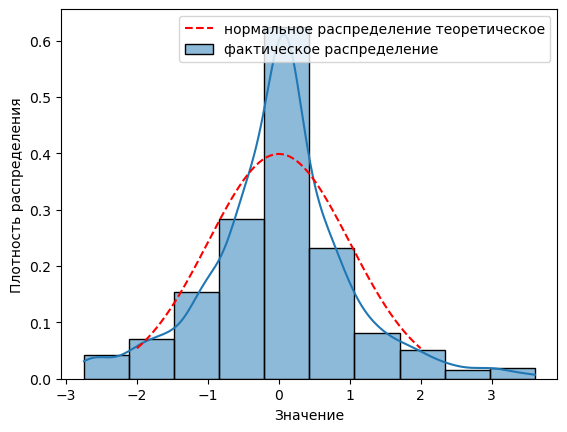

In [541]:
sns.histplot(x_scaled.T[1], kde=True, stat="density", bins=10, label='фактическое распределение');
plt.plot(xx, check_distr, 'r--', label='нормальное распределение теоретическое');
plt.xlabel('Значение');
plt.ylabel('Плотность распределения');
plt.legend();

Делаем вывод, что стандартизация данных на самом деле привела к нормальному распределению признака